# Goal

1: Split Data into:
**Training Set(70%)
**Validation Set(15%)
**Test Set(15%)
<br>
2: Applying Logistic Regression and Evaluation
<br>
3: Applying Random Forest and Evaluation
<br>
4: Applying XGBoost and Evaluation

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

#First splitting into 70% and 30%

x = pd.read_csv("../dataset/preprocessed_churn.csv")

y = pd.read_csv("../dataset/target.csv").squeeze()  # Convert to Series
#Converted to series to avoid issues with shape during splitting
#As model expects 1D array for target variable

#We would not have needed to do this if we had done
#all of that in a single notebook, but since we are doing it in multiple notebooks, we need to save the preprocessed data and target variable separately and then load them here for splitting
#but when we saved target variable, we saved it as a dataframe, so we need to convert it to series before splitting
#If we had done all of this in a single notebook, we could have just kept it as a series and then we would not have needed to convert it back to series here

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

In [2]:
#Now splitting the remaining 30% into 15% and 15%

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print(x_train.shape, x_val.shape, x_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

#Now we have our training, validation, and test sets ready for model training and evaluation
#We move to the model training and evaluation step

(4930, 30) (1056, 30) (1057, 30)
(4930,) (1056,) (1057,)


In [4]:
#Logistic Regression

#importing the logistic regression model from sklearn
from sklearn.linear_model import LogisticRegression

#initializing the logistic regression model with a maximum of 1000 iterations to ensure convergence
model = LogisticRegression(max_iter=1000)

#fitting the model on the training data
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [5]:
#Predicting
y_pred = model.predict(x_test)

In [7]:
#Probability predictions
y_prob = model.predict_proba(x_test)[:, 1]  # Probability of the positive class

#Quick check of predictions
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

Predicted labels: [0 0 0 0 0 0 0 0 0 1]
Predicted probabilities: [0.42075829 0.09176882 0.02876121 0.15470277 0.00659054 0.13932623
 0.00308075 0.08529468 0.12283148 0.73126368]


In [8]:
#Evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8107852412488175
Precision: 0.6866359447004609
Recall: 0.5302491103202847
F1 Score: 0.5983935742971888
ROC AUC Score: 0.8445995524085556


🧠 GOLDEN INTERPRETATION

The model achieves good overall accuracy and ROC-AUC score, indicating strong classification capability. However, the relatively low recall suggests that a significant number of churn cases are not being detected, which may negatively impact business outcomes.

In [12]:
#Now we move to the next model, which is Random Forest
#It combines multiple decision trees to make better predictions and is less prone to overfitting than a single decision tree. It can capture complex relationships in the data and often provides better performance than logistic regression, especially on larger datasets with many features. We will implement it now.

#importing the random forest classifier from sklearn
from sklearn.ensemble import RandomForestClassifier

#initializing the model
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

#training the model on the training data
rf_model.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

In [13]:
#predicting with the random forest model
y_pred_rf = rf_model.predict(x_test)
#probability predictions with random forest
y_prob_rf = rf_model.predict_proba(x_test)[:, 1]

In [14]:
#Quick Check
print("Random Forest Predicted labels:", y_pred_rf[:10])
print("Random Forest Predicted probabilities:", y_prob_rf[:10])

Random Forest Predicted labels: [0 0 0 0 0 0 0 0 0 1]
Random Forest Predicted probabilities: [0.41 0.17 0.15 0.21 0.05 0.34 0.05 0.17 0.08 0.99]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7918637653736992
Precision: 0.6431924882629108
Recall: 0.4875444839857651
F1 Score: 0.5546558704453441
ROC AUC Score: 0.8179733646402758


| Metric    | Logistic Regression | Random Forest |
| --------- | ------------------- | ------------- |
| Accuracy  | **0.81**            | 0.79 ↓        |
| Precision | **0.69**            | 0.64 ↓        |
| Recall    | **0.53**            | 0.49 ↓        |
| F1 Score  | **0.60**            | 0.55 ↓        |
| AUC       | **0.84**            | 0.82 ↓        |

Logistic Regression outperforms Random Forest across all evaluation metrics, particularly in recall and ROC-AUC score. This suggests that the dataset exhibits patterns that are well captured by linear decision boundaries, and additional model complexity does not improve performance.


In [16]:
#Now we apply XGBoost model

#importing
from xgboost import XGBClassifier

#initializing the model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

#training the model
xgb_model.fit(x_train, y_train)

#predicting with the XGBoost Model
y_pred_xgb = xgb_model.predict(x_test)
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]

C:\Users\rishe\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [08:00:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [17]:
print(y_pred_xgb[:10])
print(y_prob_xgb[:10])

[0 0 0 0 0 0 0 0 0 1]
[0.44703993 0.10045795 0.02857435 0.18617444 0.00435913 0.15328291
 0.00337994 0.05838495 0.09436984 0.885677  ]


In [18]:
#Evaluate XgBoost
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.7890255439924314
Precision: 0.6342592592592593
Recall: 0.4875444839857651
F1 Score: 0.5513078470824949
ROC AUC Score: 0.8245175551234546


| Metric    | Logistic Regression | Random Forest | XGBoost |
| --------- | ------------------- | ------------- | ------- |
| Accuracy  | **0.81**            | 0.79          | 0.79    |
| Precision | **0.69**            | 0.64          | 0.63    |
| Recall    | **0.53**            | 0.49          | 0.48    |
| F1 Score  | **0.60**            | 0.55          | 0.55    |
| ROC-AUC   | **0.84**            | 0.82          | 0.82    |


Logistic Regression outperforms Random Forest and XGBoost across all evaluation metrics. Despite being a simpler model, it captures the underlying patterns effectively, while more complex ensemble methods fail to provide performance improvements. This indicates that the dataset is well-suited for linear decision boundaries, and increasing model complexity does not necessarily enhance predictive capability.

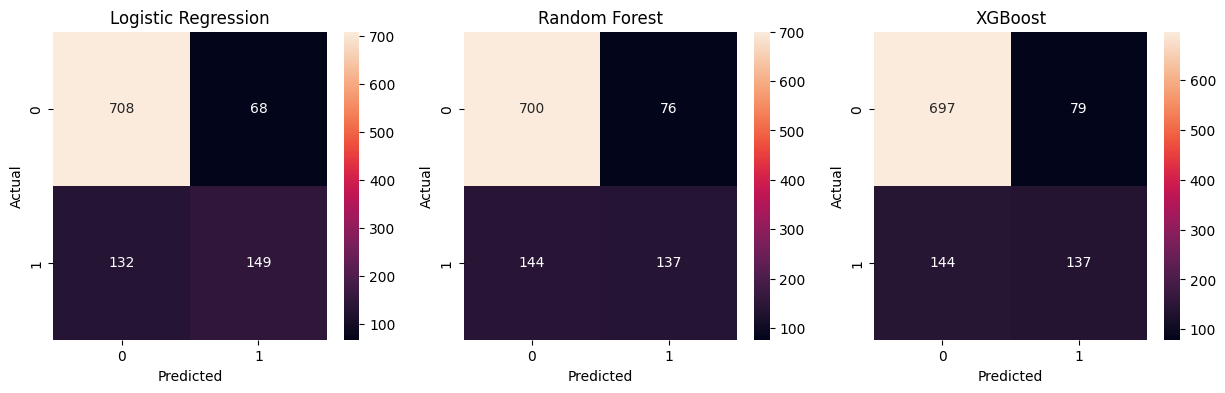

In [19]:
#Now we will compare the Confusion Matrices of all the models

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)


# Plot all
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Random Forest")

sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("XGBoost")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.show()

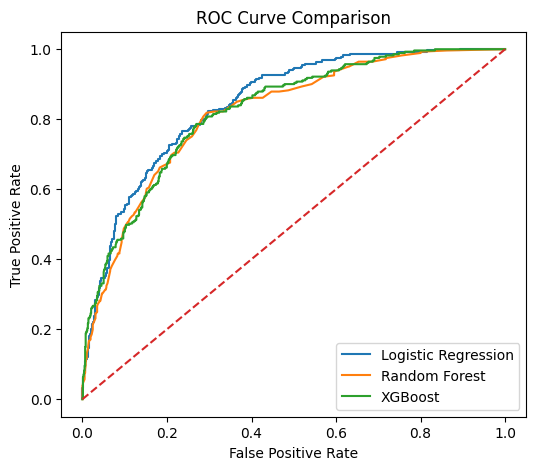

In [20]:
#We will compare the ROC curve of all models
from sklearn.metrics import roc_curve

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)


# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

Now we will compare:
<br>
-Accuracy
<br>
-Precision
<br>
-Recall
<br>
-F1 Score
<br>
-ROC AUC

for all 3 models...

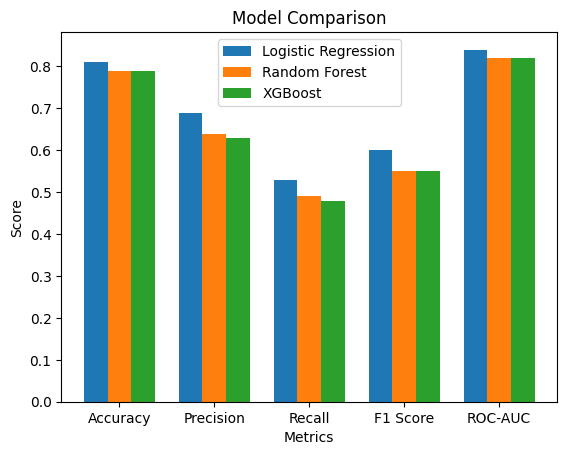

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for each model
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

log_reg = [0.81, 0.69, 0.53, 0.60, 0.84]
random_forest = [0.79, 0.64, 0.49, 0.55, 0.82]
xgboost = [0.79, 0.63, 0.48, 0.55, 0.82]

# X-axis positions
x = np.arange(len(metrics))
width = 0.25

# Plot
plt.figure()

plt.bar(x - width, log_reg, width, label='Logistic Regression')
plt.bar(x, random_forest, width, label='Random Forest')
plt.bar(x + width, xgboost, width, label='XGBoost')

# Labels
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Comparison")

plt.xticks(x, metrics)
plt.legend()

plt.show()

The bar chart clearly shows that Logistic Regression outperforms Random Forest and XGBoost across all evaluation metrics. Despite being a simpler model, it achieves higher accuracy, precision, recall, F1-score, and ROC-AUC, reinforcing the conclusion that increased model complexity does not guarantee better performance.